# Análise de Dados Meteorológicos – INMET

**Objetivo:**  
Realizar a leitura, organização, limpeza e análise exploratória de dados meteorológicos
disponibilizados pelo INMET, com foco em padronização de variáveis e geração de estatísticas
descritivas.

**Fonte dos dados:** INMET – Estação A807  
**Período analisado:** 2025-01-01 – 2025-12-31

## 1. Importação de bibliotecas

In [1]:
from google.colab import files

uploaded = files.upload()


Saving dados_A807_D_2025-01-01_2025-12-31.csv to dados_A807_D_2025-01-01_2025-12-31.csv


## 2. Leitura dos dados

Os dados foram baixados diretamente do site do INMET e importados para o ambiente Colab no formato CSV.


In [2]:
import pandas as pd
import io

# Get the filename from the 'uploaded' dictionary. Using the available file.
filename = next(iter(uploaded))
print(f'Reading data from: {filename}')

# Read the uploaded CSV file into a pandas DataFrame with the identified parameters
# Skipping 9 rows to reach the actual header (10th line), and using that line as header.
df = pd.read_csv(io.BytesIO(uploaded[filename]), sep=';', skiprows=9, header=0, engine='python')

# Display the first few rows of the DataFrame to confirm it's loaded correctly
display(df.head(10))

Reading data from: dados_A807_D_2025-01-01_2025-12-31.csv


,Data Medicao,"PRECIPITACAO TOTAL, DIARIO (AUT)(mm)","TEMPERATURA MEDIA, DIARIA (AUT)(°C)","UMIDADE RELATIVA DO AR, MEDIA DIARIA (AUT)(%)","VENTO, RAJADA MAXIMA DIARIA (AUT)(m/s)",Unnamed: 5
0,2025-01-01,0.2,21.8,78.8,10.3,NaN
1,2025-01-02,0.0,21.5,79.5,13.7,NaN
2,2025-01-03,4.4,23.2,73.0,9.4,NaN
3,2025-01-04,0.0,23.9,68.4,10.6,NaN
4,2025-01-05,0.0,20.9,80.1,9.2,NaN
5,2025-01-06,0.0,20.6,80.7,7.4,NaN
6,2025-01-07,1.4,19.8,87.1,7.8,NaN
7,2025-01-08,2.6,19.2,87.3,8.4,NaN
8,2025-01-09,11.0,19.2,82.3,9.8,NaN
9,2025-01-10,0.0,19.5,78.2,9.8,NaN


## 3. Padronização e organização das variáveis

As colunas originais apresentavam nomes longos e inconsistentes.
Foi realizada a padronização para facilitar a análise e a reprodutibilidade do código.

In [3]:
df.columns

Index(['Data Medicao', 'PRECIPITACAO TOTAL, DIARIO (AUT)(mm)',
       'TEMPERATURA MEDIA, DIARIA (AUT)(°C)',
       'UMIDADE RELATIVA DO AR, MEDIA DIARIA (AUT)(%)',
       'VENTO, RAJADA MAXIMA DIARIA (AUT)(m/s)', 'Unnamed: 5'],
      dtype='object')

In [4]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace(',', '', regex=False)   # remove vírgulas
    .str.replace('/', '_', regex=False)  # troca / por _
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
    .str.replace('%', 'pct', regex=False)
    .str.replace('°c', 'c', regex=False)
)


### 3.1 Conferência de Tipos de dados (dtypes)

Nesta etapa foi realizada a verificação dos tipos de dados (dtypes) de cada variável do conjunto de dados, com o objetivo de garantir que as colunas estejam corretamente interpretadas pelo pandas para as análises subsequentes.

A conferência dos dtypes é fundamental, pois dados meteorológicos frequentemente são importados como texto (object), mesmo quando representam valores numéricos ou datas, o que pode comprometer cálculos estatísticos, análises temporais e visualizações.

Após a leitura dos dados, foram identificadas colunas que necessitavam de conversão para os tipos adequados, como numérico (float) e data (datetime), assegurando maior consistência e confiabilidade nas análises.

O esperado:

*   data_medicao → datetime64[ns]
*   todas as outras → float64

Se aparecer object em alguma coluna (fora a data) → tem problema.

In [5]:
df['data_medicao'] = pd.to_datetime(df['data_medicao'])
df.dtypes

,0
data_medicao,datetime64[ns]
precipitacao_total_diario_autmm,float64
temperatura_media_diaria_autc,float64
umidade_relativa_do_ar_media_diaria_autpct,float64
vento_rajada_maxima_diaria_autm_s,float64
unnamed:_5,float64


### 3.2 Garantia de consistência das colunas numéricas

Nesta etapa foi realizada a verificação e padronização das colunas numéricas do conjunto de dados, com o objetivo de assegurar que todas as variáveis utilizadas em cálculos estatísticos estejam corretamente definidas como numéricas.

Inicialmente, **foram removidas colunas auxiliares geradas durante a importação do arquivo (como colunas do tipo *Unnamed*)**, que não possuem significado analítico.

**Em seguida, todas as colunas numéricas, com exceção da variável de data, foram explicitamente convertidas para o tipo numérico**. Valores que não puderam ser convertidos (como strings ou registros inconsistentes) foram transformados em NaN, permitindo tratamento posterior adequado.

Esse procedimento garante maior confiabilidade nas análises estatísticas, evita erros silenciosos em operações matemáticas e assegura a integridade dos resultados obtidos.

In [7]:
df = df.loc[:, ~df.columns.str.contains('unnamed')]
cols_numericas = df.columns.drop('data_medicao')

df[cols_numericas] = df[cols_numericas].apply(
    pd.to_numeric, errors='coerce'
)

In [ ]:
df.head(10)

,data_medicao,precipitacao_total_diario_autmm,temperatura_media_diaria_autc,umidade_relativa_do_ar_media_diaria_autpct,vento_rajada_maxima_diaria_autm_s
0,2025-01-01,0.2,21.8,78.8,10.3
1,2025-01-02,0.0,21.5,79.5,13.7
2,2025-01-03,4.4,23.2,73.0,9.4
3,2025-01-04,0.0,23.9,68.4,10.6
4,2025-01-05,0.0,20.9,80.1,9.2
5,2025-01-06,0.0,20.6,80.7,7.4
6,2025-01-07,1.4,19.8,87.1,7.8
7,2025-01-08,2.6,19.2,87.3,8.4
8,2025-01-09,11.0,19.2,82.3,9.8
9,2025-01-10,0.0,19.5,78.2,9.8


In [8]:
df.columns

Index(['data_medicao', 'precipitacao_total_diario_autmm',
       'temperatura_media_diaria_autc',
       'umidade_relativa_do_ar_media_diaria_autpct',
       'vento_rajada_maxima_diaria_autm_s'],
      dtype='object')

In [9]:
print('Current columns in df:', df.columns.tolist())
df[['data_medicao', 'precipitacao_total_diario_autmm']].head(10)

Current columns in df: ['data_medicao', 'precipitacao_total_diario_autmm', 'temperatura_media_diaria_autc', 'umidade_relativa_do_ar_media_diaria_autpct', 'vento_rajada_maxima_diaria_autm_s']


,data_medicao,precipitacao_total_diario_autmm
0,2025-01-01,0.2
1,2025-01-02,0.0
2,2025-01-03,4.4
3,2025-01-04,0.0
4,2025-01-05,0.0
5,2025-01-06,0.0
6,2025-01-07,1.4
7,2025-01-08,2.6
8,2025-01-09,11.0
9,2025-01-10,0.0


## 4. Análise estatística descritiva - Medidas Resumo e Valores Ausentes (Antes do Tratamento)

As medidas estatísticas descritivas foram utilizadas não apenas para resumir o comportamento das variáveis numéricas, mas também como instrumento auxiliar para a identificação e avaliação de valores ausentes no conjunto de dados.

A partir das estatísticas geradas (como contagem, média, valores mínimos e máximos), foi possível verificar a presença de registros ausentes (NaN) e compreender seu impacto potencial sobre as análises.

In [10]:
display(df.shape)
df.info()

# Get descriptive statistics for numerical columns
numeric_desc = df.select_dtypes(include=['number']).describe()

# Get NaN counts for numerical columns
na_counts_series = df.select_dtypes(include=['number']).isna().sum()

# Convert the Series to a DataFrame row with a specific index name
na_counts_df_row = pd.DataFrame([na_counts_series], index=['NaN Count'])

# Concatenate this new row to the descriptive statistics DataFrame
combined_desc = pd.concat([numeric_desc, na_counts_df_row])

display(combined_desc)

(365, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 5 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   data_medicao                                365 non-null    datetime64[ns]
 1   precipitacao_total_diario_autmm             315 non-null    float64       
 2   temperatura_media_diaria_autc               314 non-null    float64       
 3   umidade_relativa_do_ar_media_diaria_autpct  353 non-null    float64       
 4   vento_rajada_maxima_diaria_autm_s           352 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 14.4 KB


,precipitacao_total_diario_autmm,temperatura_media_diaria_autc,umidade_relativa_do_ar_media_diaria_autpct,vento_rajada_maxima_diaria_autm_s
count,315.000000,314.000000,353.000000,352.000000
mean,3.638730,18.652866,80.047309,8.772443
std,8.260559,3.825784,7.921895,2.755302
min,0.000000,8.500000,44.100000,3.900000
25%,0.000000,16.200000,75.600000,7.100000
50%,0.000000,18.800000,80.900000,8.400000
75%,3.100000,21.500000,85.800000,9.700000
max,56.800000,27.400000,96.000000,22.900000
NaN Count,50.000000,51.000000,12.000000,13.000000


## 5. Limpeza e tratamento dos dados

Foram identificados valores ausentes e inconsistências, tratados conforme os seguintes critérios:

**Tratamento de dados:**

Precipitação → substituir NaN por 0

Temperatura / umidade / vento → interpolar

In [12]:
df['precipitacao_total_diario_autmm'] = df['precipitacao_total_diario_autmm'].fillna(0)

df = df.sort_values('data_medicao')

df[['temperatura_media_diaria_autc',
    'umidade_relativa_do_ar_media_diaria_autpct',
    'vento_rajada_maxima_diaria_autm_s']] = (
    df[['temperatura_media_diaria_autc',
        'umidade_relativa_do_ar_media_diaria_autpct',
        'vento_rajada_maxima_diaria_autm_s']]
    .interpolate()
)


### 5.1 Verificação da Interpolação

Nesta etapa foi realizada a conferência da presença de valores ausentes (*NaN*) nas principais variáveis numéricas como forma de verificação do procedimento de tratamento aplicado. <br>
A presença de valores diferentes de zero indica possível falha no processo de interpolação, enquanto a ausência de *NaN* confirma a efetividade do tratamento realizado.

In [13]:
df[['temperatura_media_diaria_autc',
    'umidade_relativa_do_ar_media_diaria_autpct',
    'vento_rajada_maxima_diaria_autm_s',
    'precipitacao_total_diario_autmm']].isna().sum()

,0
temperatura_media_diaria_autc,0
umidade_relativa_do_ar_media_diaria_autpct,0
vento_rajada_maxima_diaria_autm_s,0
precipitacao_total_diario_autmm,0


Para verificar se os dados foram corretamente carregados e tratados, foram inspecionados os 10 primeiros registros do conjunto de dados, permitindo conferir o início da série temporal e o formato das variáveis.

Em seguida, foram analisados os 10 últimos registros, com o objetivo de validar o final da série temporal e garantir que não permanecem valores faltantes ou inconsistências após o tratamento dos dados.

In [14]:
display(df[['data_medicao',
    'temperatura_media_diaria_autc',
    'umidade_relativa_do_ar_media_diaria_autpct',
    'vento_rajada_maxima_diaria_autm_s']].head(10))
display(df[['data_medicao',
    'temperatura_media_diaria_autc',
    'umidade_relativa_do_ar_media_diaria_autpct',
    'vento_rajada_maxima_diaria_autm_s']].tail(10))

,data_medicao,temperatura_media_diaria_autc,umidade_relativa_do_ar_media_diaria_autpct,vento_rajada_maxima_diaria_autm_s
0,2025-01-01,21.8,78.8,10.3
1,2025-01-02,21.5,79.5,13.7
2,2025-01-03,23.2,73.0,9.4
3,2025-01-04,23.9,68.4,10.6
4,2025-01-05,20.9,80.1,9.2
5,2025-01-06,20.6,80.7,7.4
6,2025-01-07,19.8,87.1,7.8
7,2025-01-08,19.2,87.3,8.4
8,2025-01-09,19.2,82.3,9.8
9,2025-01-10,19.5,78.2,9.8


,data_medicao,temperatura_media_diaria_autc,umidade_relativa_do_ar_media_diaria_autpct,vento_rajada_maxima_diaria_autm_s
355,2025-12-22,25.0,66.1,8.9
356,2025-12-23,26.2,64.6,9.7
357,2025-12-24,27.4,54.7,9.5
358,2025-12-25,25.6,71.3,17.9
359,2025-12-26,25.9,67.3,8.7
360,2025-12-27,25.8,70.5,8.6
361,2025-12-28,26.3,65.9,8.8
362,2025-12-29,24.4,77.6,9.3
363,2025-12-30,23.8,80.3,10.9
364,2025-12-31,23.0,82.6,11.0


Logo após, a análise dos limites mínimo e máximo indicou que os valores permanecem dentro de faixas plausíveis, reforçando a confiabilidade dos dados para as análises subsequentes.

In [15]:
print('Checking for negative humidity values:')
display(df[df['umidade_relativa_do_ar_media_diaria_autpct'] < 0])

print('\nChecking for minimum and maximum values of interpolated columns:')
min_max_check = df[['temperatura_media_diaria_autc',
                    'umidade_relativa_do_ar_media_diaria_autpct',
                    'vento_rajada_maxima_diaria_autm_s']].agg(['min', 'max'])
display(min_max_check)

Checking for negative humidity values:


,data_medicao,precipitacao_total_diario_autmm,temperatura_media_diaria_autc,umidade_relativa_do_ar_media_diaria_autpct,vento_rajada_maxima_diaria_autm_s



Checking for minimum and maximum values of interpolated columns:


,temperatura_media_diaria_autc,umidade_relativa_do_ar_media_diaria_autpct,vento_rajada_maxima_diaria_autm_s
min,8.5,44.1,3.9
max,27.4,96.0,22.9


## 6. Análise estatística descritiva - Medidas Resumo e Valores Ausentes (Pós Tratamento)

Após a etapa de limpeza e tratamento dos dados, foram calculadas as medidas estatísticas descritivas, com o objetivo de avaliar os efeitos do tratamento aplicado ao conjunto de dados.

In [16]:
display(df.shape)
df.info()

# Get descriptive statistics for numerical columns
numeric_desc = df.select_dtypes(include=['number']).describe()

# Get NaN counts for numerical columns
na_counts_series = df.select_dtypes(include=['number']).isna().sum()

# Convert the Series to a DataFrame row with a specific index name
na_counts_df_row = pd.DataFrame([na_counts_series], index=['NaN Count'])

# Concatenate this new row to the descriptive statistics DataFrame
combined_desc = pd.concat([numeric_desc, na_counts_df_row])

display(combined_desc)

(365, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 5 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   data_medicao                                365 non-null    datetime64[ns]
 1   precipitacao_total_diario_autmm             365 non-null    float64       
 2   temperatura_media_diaria_autc               365 non-null    float64       
 3   umidade_relativa_do_ar_media_diaria_autpct  365 non-null    float64       
 4   vento_rajada_maxima_diaria_autm_s           365 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 14.4 KB


,precipitacao_total_diario_autmm,temperatura_media_diaria_autc,umidade_relativa_do_ar_media_diaria_autpct,vento_rajada_maxima_diaria_autm_s
count,365.000000,365.000000,365.000000,365.000000
mean,3.140274,18.065753,80.120959,8.772466
std,7.773882,3.932087,7.826752,2.733322
min,0.000000,8.500000,44.100000,3.900000
25%,0.000000,15.300000,75.800000,7.100000
50%,0.000000,18.200000,81.000000,8.400000
75%,1.600000,21.200000,85.800000,9.700000
max,56.800000,27.400000,96.000000,22.900000
NaN Count,0.000000,0.000000,0.000000,0.000000


## 7. Conferência da ordenação temporal dos dados




Após a aplicação das medidas resumo e do tratamento dos dados, foi realizada a conferência da ordenação temporal do conjunto de dados, garantindo que os registros estejam organizados de forma cronológica com base na variável de data.

In [17]:
df['data_medicao'].is_monotonic_increasing


True

In [18]:
df[['data_medicao']].head()
df[['data_medicao']].tail()


,data_medicao
360,2025-12-27
361,2025-12-28
362,2025-12-29
363,2025-12-30
364,2025-12-31


## 8. Visualização da evolução temporal das variáveis

Inicialmente, foram construídos gráficos de linha para as quatro variáveis analisadas, com o objetivo de visualizar sua evolução ao longo do tempo e identificar padrões gerais de comportamento.

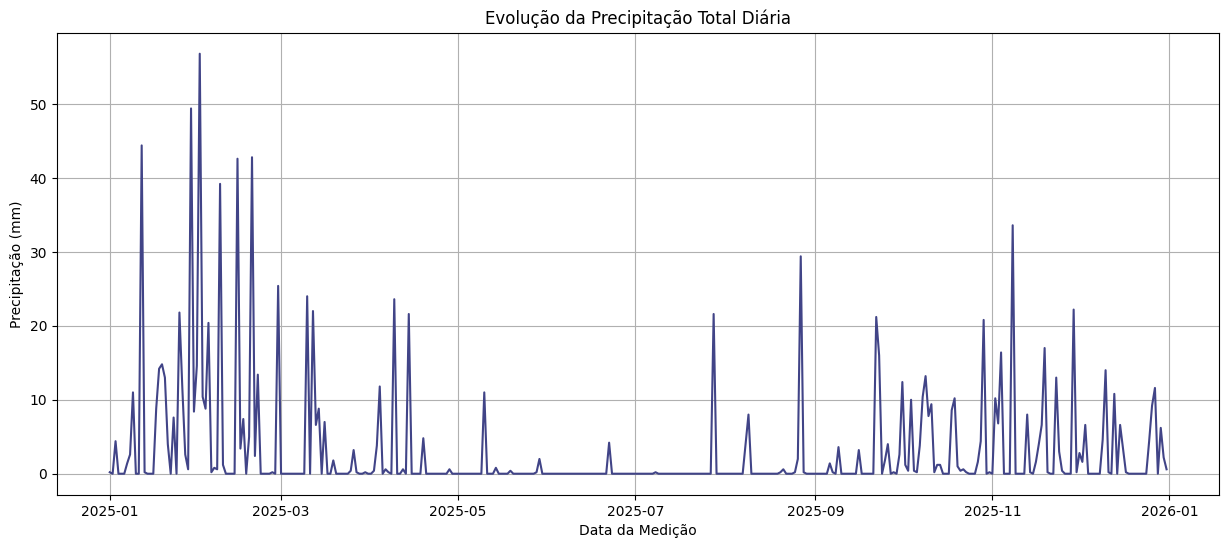

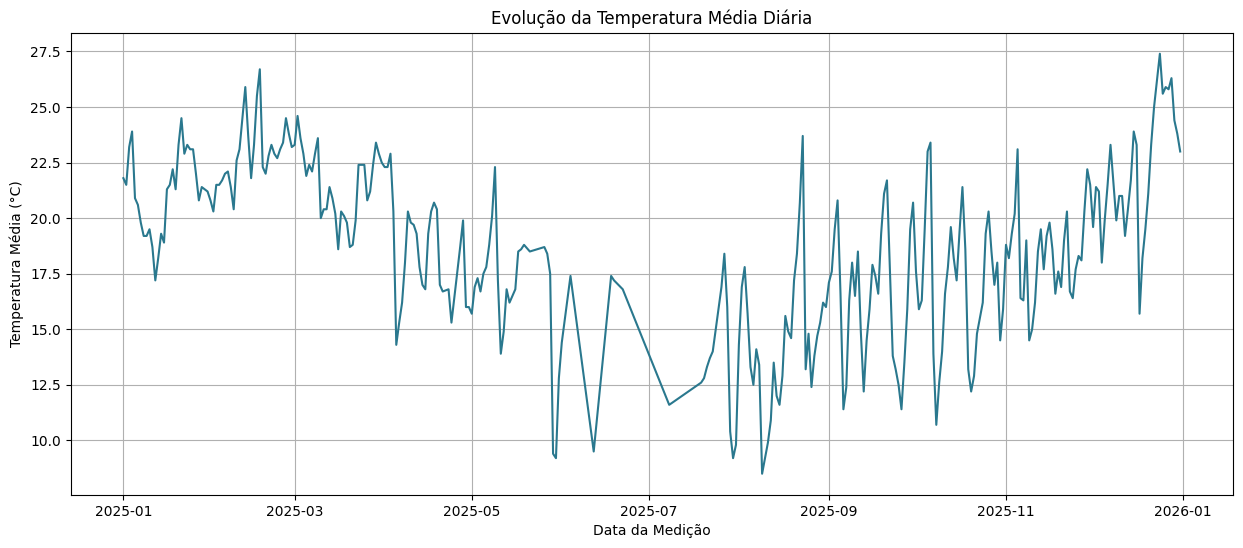

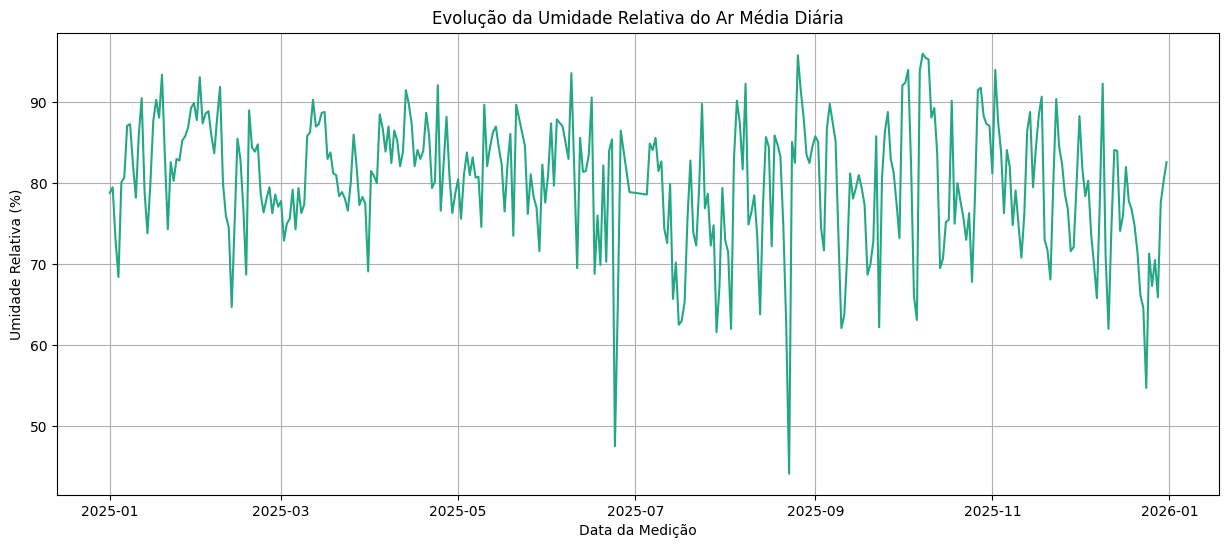

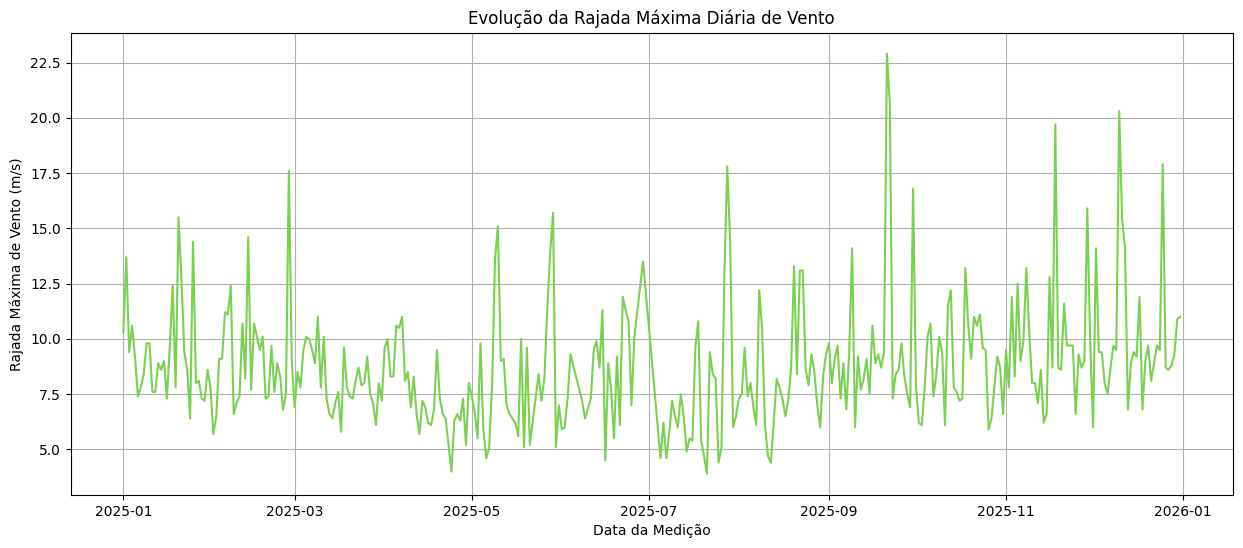

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a color palette for the four plots
colors = sns.color_palette('viridis', 4)

# Plot for Precipitação
plt.figure(figsize=(15, 6))
sns.lineplot(x='data_medicao', y='precipitacao_total_diario_autmm', data=df, color=colors[0])
plt.title('Evolução da Precipitação Total Diária')
plt.xlabel('Data da Medição')
plt.ylabel('Precipitação (mm)')
plt.grid(True)
plt.show()

# Plot for Temperatura Média Diária
plt.figure(figsize=(15, 6))
sns.lineplot(x='data_medicao', y='temperatura_media_diaria_autc', data=df, color=colors[1])
plt.title('Evolução da Temperatura Média Diária')
plt.xlabel('Data da Medição')
plt.ylabel('Temperatura Média (°C)')
plt.grid(True)
plt.show()

# Plot for Umidade Relativa do Ar Média Diária
plt.figure(figsize=(15, 6))
sns.lineplot(x='data_medicao', y='umidade_relativa_do_ar_media_diaria_autpct', data=df, color=colors[2])
plt.title('Evolução da Umidade Relativa do Ar Média Diária')
plt.xlabel('Data da Medição')
plt.ylabel('Umidade Relativa (%)')
plt.grid(True)
plt.show()

# Plot for Vento - Rajada Máxima Diária
plt.figure(figsize=(15, 6))
sns.lineplot(x='data_medicao', y='vento_rajada_maxima_diaria_autm_s', data=df, color=colors[3])
plt.title('Evolução da Rajada Máxima Diária de Vento')
plt.xlabel('Data da Medição')
plt.ylabel('Rajada Máxima de Vento (m/s)')
plt.grid(True)
plt.show()

 ## 9. Análise de Tendência e Sazonalidade

Para cada série temporal (precipitação, temperatura, umidade relativa do ar e vento), a análise de tendência e sazonalidade seguiu o mesmo procedimento metodológico. A tendência foi avaliada por meio da média móvel, da regressão linear pelo método dos mínimos quadrados e do teste de Cox–Stuart. A sazonalidade foi investigada a partir de boxplots mensais, do teste de Kruskal–Wallis e do pós-teste de Dunn.


### 9.1 Precipitação Total Diária

#### 9.1.1 Média Móvel

<Axes: title={'center': 'Precipitação total diária e tendência (média móvel 30 dias)'}, xlabel='data_medicao'>

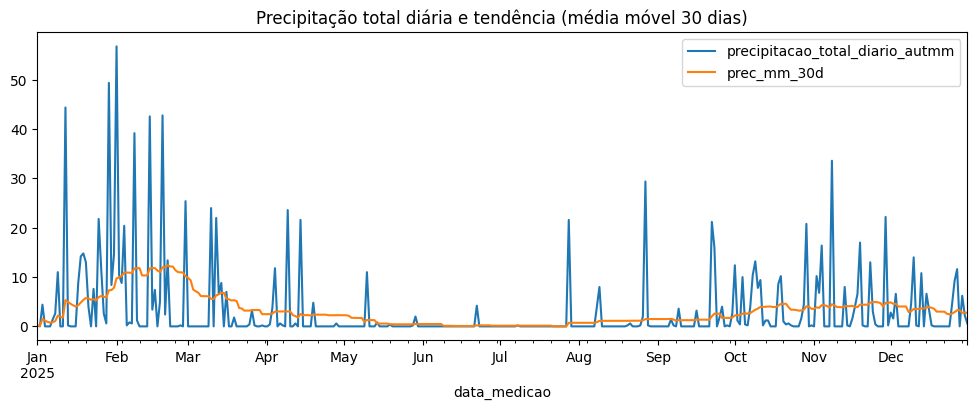

In [20]:
df['prec_mm_30d'] = df['precipitacao_total_diario_autmm'].rolling(window=30, min_periods=1).mean()

df.plot(
    x='data_medicao',
    y=['precipitacao_total_diario_autmm', 'prec_mm_30d'],
    figsize=(12,4),
    title='Precipitação total diária e tendência (média móvel 30 dias)'
)

#### 9.1.2 Regressão por Mínimos Quadrados

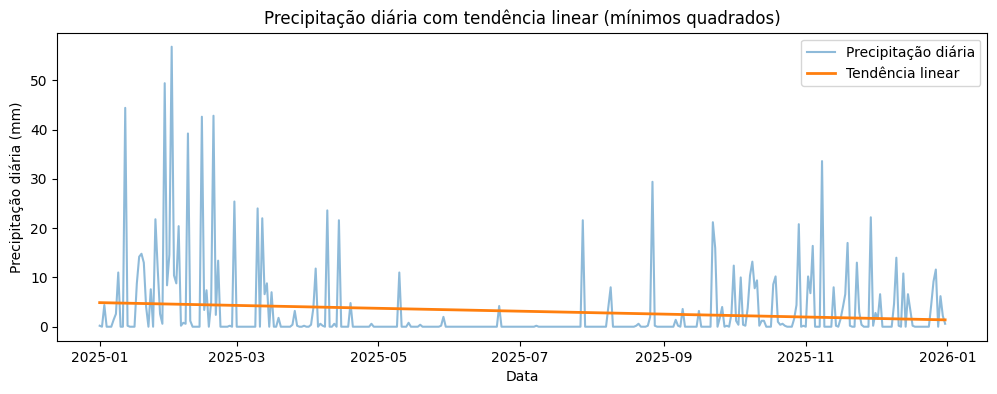

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# remover NaN
df_prec = df[['data_medicao', 'precipitacao_total_diario_autmm']].dropna()

# variável independente (tempo como índice numérico)
x = np.arange(len(df_prec))

# variável dependente
y = df_prec['precipitacao_total_diario_autmm'].values


coef = np.polyfit(x, y, 1)  # grau 1 = reta
tendencia = np.polyval(coef, x)


plt.figure(figsize=(12,4))
plt.plot(df_prec['data_medicao'], y, label='Precipitação diária', alpha=0.5)
plt.plot(df_prec['data_medicao'], tendencia, label='Tendência linear', linewidth=2)

plt.xlabel('Data')
plt.ylabel('Precipitação diária (mm)')
plt.title('Precipitação diária com tendência linear (mínimos quadrados)')
plt.legend()
plt.show()

#### 9.1.3 Teste de Cox-Stuart

In [22]:
serie_prec = df['precipitacao_total_diario_autmm'].dropna().values

import numpy as np
from scipy.stats import binomtest

def cox_stuart_test(series):
    n = len(series)
    half = n // 2

    first_half = series[:half]
    second_half = series[-half:]

    diff = second_half - first_half

    pos = np.sum(diff > 0)
    neg = np.sum(diff < 0)

    result = binomtest(pos, pos + neg, 0.5)
    return result.pvalue

p_value_prec = cox_stuart_test(serie_prec)
p_value_prec

if p_value_prec < 0.05:
    print("Existe tendência significativa na série temporal de precipitação.")
else:
    print("Não foi identificada tendência significativa na série temporal de precipitação.")



Não foi identificada tendência significativa na série temporal de precipitação.


#### 9.1.4 Boxplots Mensais

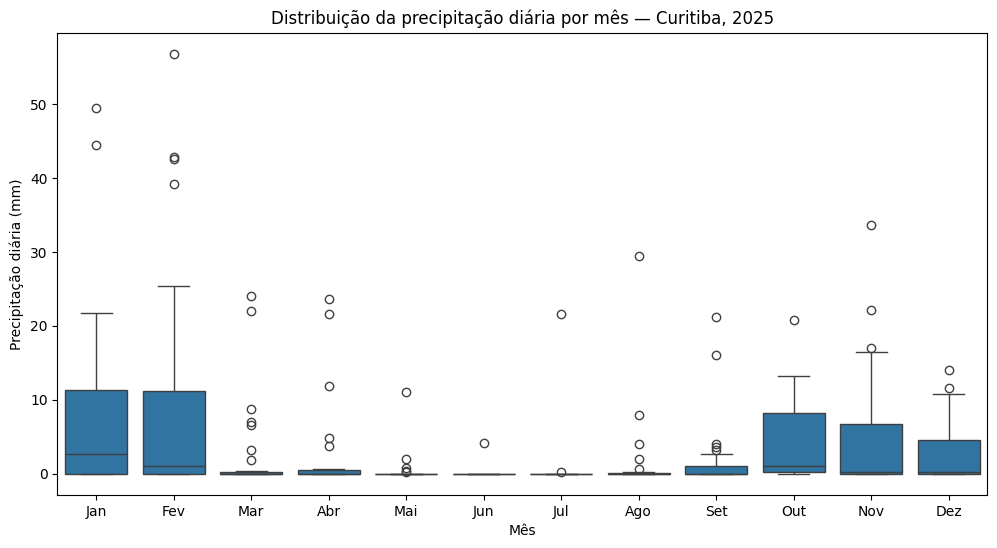

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'mes' column exists
if 'mes' not in df.columns:
    df['mes'] = df['data_medicao'].dt.month

mapa_meses = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr',
    5: 'Mai', 6: 'Jun', 7: 'Jul', 8: 'Ago',
    9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}

df['mes_nome'] = df['mes'].map(mapa_meses)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='mes_nome',
    y='precipitacao_total_diario_autmm',
    order=list(mapa_meses.values())
)

plt.xlabel('Mês')
plt.ylabel('Precipitação diária (mm)')
plt.title('Distribuição da precipitação diária por mês — Curitiba, 2025')

plt.show()

#### 9.1.5 Teste de Kruskal–Wallis

In [27]:
from scipy.stats import kruskal
import pandas as pd
import numpy as np

# Ensure 'mes' column exists (if not created by previous cells)
if 'mes' not in df.columns:
    df['mes'] = df['data_medicao'].dt.month

# Group precipitation data by month
monthly_precipitation = [group['precipitacao_total_diario_autmm'].dropna().values for name, group in df.groupby('mes')]

# Perform Kruskal-Wallis H-test
h_statistic, p_value = kruskal(*monthly_precipitation)

print(f"Kruskal-Wallis H-statistic: {h_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Existe uma diferença estatisticamente significativa na precipitação entre os meses.")
else:
    print("Não há evidência de uma diferença estatisticamente significativa na precipitação entre os meses.")

Kruskal-Wallis H-statistic: 80.86
P-value: 0.000
Existe uma diferença estatisticamente significativa na precipitação entre os meses.


#### 9.1.6 Pós-teste de Dunn

In [44]:
!pip install scikit-posthocs

import scikit_posthocs as sp

# garantir coluna mês
df['mes'] = df['data_medicao'].dt.month

dunn_precipitacao = sp.posthoc_dunn(
    df,
    val_col='precipitacao_total_diario_autmm',
    group_col='mes',
    p_adjust='bonferroni'
)

dunn_precipitacao
dunn_precipitacao < 0.05

,1,2,3,4,5,6,7,8,9,10,11,12
1,False,False,False,False,True,True,True,True,False,False,False,False
2,False,False,False,False,True,True,True,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
5,True,True,False,False,False,False,False,False,False,True,False,False
6,True,True,False,False,False,False,False,False,False,True,True,True
7,True,True,False,False,False,False,False,False,False,True,True,True
8,True,True,False,False,False,False,False,False,False,True,False,False
9,False,False,False,False,False,False,False,False,False,False,False,False
10,False,False,False,False,True,True,True,True,False,False,False,False


A precipitação diária em Curitiba no ano de 2025 apresentou comportamento sazonal. O teste de Kruskal–Wallis indicou diferenças estatisticamente significativas entre os meses, e o pós-teste de Dunn mostrou que essas diferenças ocorrem principalmente entre meses de estações distintas. Meses consecutivos tendem a ter comportamento semelhante, enquanto verão e inverno apresentam contrastes mais marcantes, em concordância com o padrão climatológico da região.

### 9.2 Temperatura Média Diária

#### 9.2.1 Média Móvel

<Axes: title={'center': 'Temperatura média diária e tendência (média móvel 30 dias)'}, xlabel='data_medicao'>

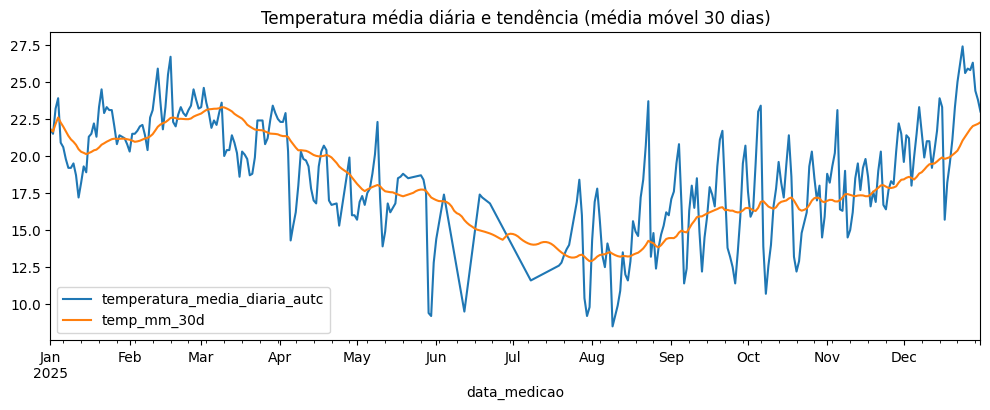

In [28]:
df['temp_mm_30d'] = df['temperatura_media_diaria_autc'].rolling(window=30, min_periods=1).mean()

df.plot(
    x='data_medicao',
    y=['temperatura_media_diaria_autc', 'temp_mm_30d'],
    figsize=(12,4),
    title='Temperatura média diária e tendência (média móvel 30 dias)'
)

#### 9.2.2 Regressão por Mínimos Quadrados

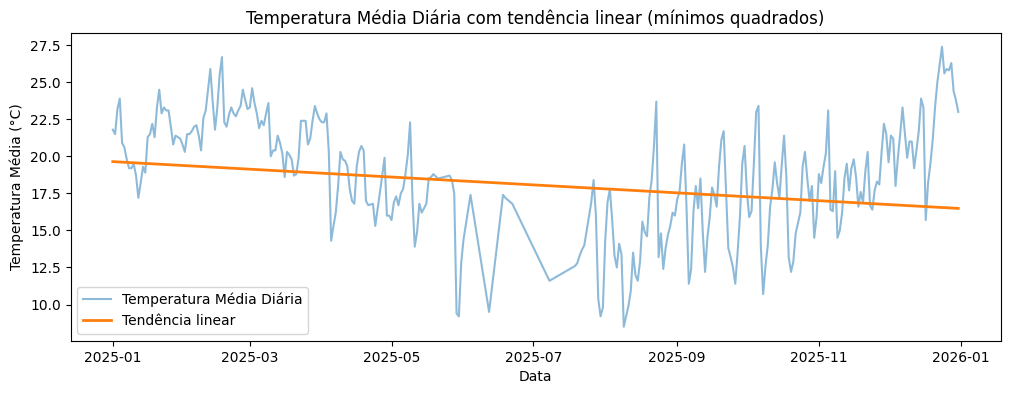

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# remover NaN
df_temp = df[['data_medicao', 'temperatura_media_diaria_autc']].dropna()

# variável independente (tempo como índice numérico)
x = np.arange(len(df_temp))

# variável dependente
y = df_temp['temperatura_media_diaria_autc'].values


coef = np.polyfit(x, y, 1)  # grau 1 = reta
tendencia = np.polyval(coef, x)


plt.figure(figsize=(12,4))
plt.plot(df_temp['data_medicao'], y, label='Temperatura Média Diária', alpha=0.5)
plt.plot(df_temp['data_medicao'], tendencia, label='Tendência linear', linewidth=2)

plt.xlabel('Data')
plt.ylabel('Temperatura Média (°C)')
plt.title('Temperatura Média Diária com tendência linear (mínimos quadrados)')
plt.legend()
plt.show()

#### 9.2.3 Teste de Cox-Stuart

In [30]:
serie_temp = df['temperatura_media_diaria_autc'].dropna().values

import numpy as np
from scipy.stats import binomtest

def cox_stuart_test(series):
    n = len(series)
    half = n // 2

    first_half = series[:half]
    second_half = series[-half:]

    diff = second_half - first_half

    pos = np.sum(diff > 0)
    neg = np.sum(diff < 0)

    result = binomtest(pos, pos + neg, 0.5)
    return result.pvalue

p_value_temp = cox_stuart_test(serie_temp)
p_value_temp

if p_value_temp < 0.05:
    print("Existe tendência significativa na série temporal de temperatura.")
else:
    print("Não foi identificada tendência significativa na série temporal de temperatura.")

Existe tendência significativa na série temporal de temperatura.


#### 9.2.4 Boxplots Mensais

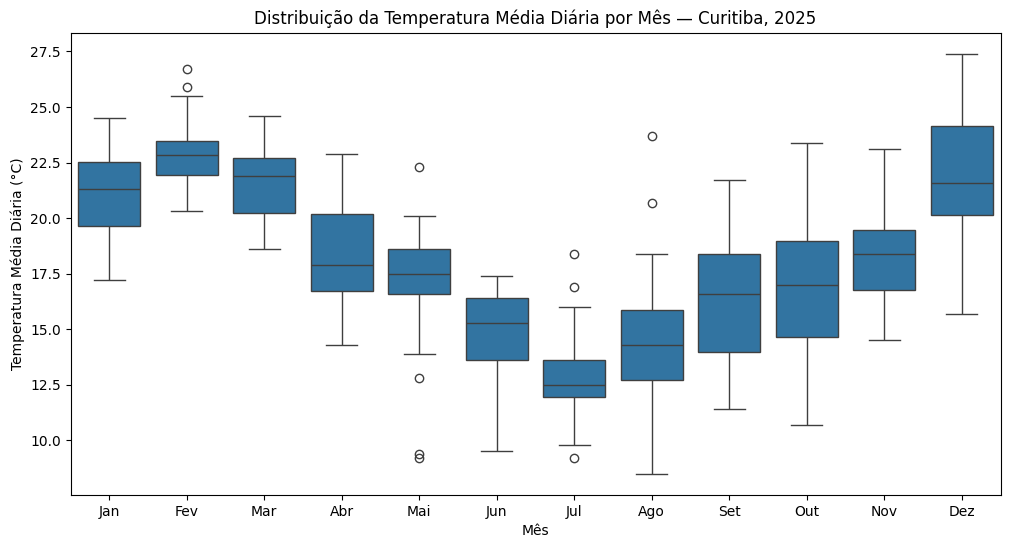

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'mes' column exists
if 'mes' not in df.columns:
    df['mes'] = df['data_medicao'].dt.month

mapa_meses = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr',
    5: 'Mai', 6: 'Jun', 7: 'Jul', 8: 'Ago',
    9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}

df['mes_nome'] = df['mes'].map(mapa_meses)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='mes_nome',
    y='temperatura_media_diaria_autc',
    order=list(mapa_meses.values())
)

plt.xlabel('Mês')
plt.ylabel('Temperatura Média Diária (°C)')
plt.title('Distribuição da Temperatura Média Diária por Mês — Curitiba, 2025')

plt.show()

#### 9.2.5 Teste de Kruskal–Wallis

In [33]:
from scipy.stats import kruskal
import pandas as pd
import numpy as np

# Ensure 'mes' column exists (if not created by previous cells)
if 'mes' not in df.columns:
    df['mes'] = df['data_medicao'].dt.month

# Group temperature data by month
monthly_temperature = [group['temperatura_media_diaria_autc'].dropna().values for name, group in df.groupby('mes')]

# Perform Kruskal-Wallis H-test
h_statistic, p_value = kruskal(*monthly_temperature)

print(f"Kruskal-Wallis H-statistic: {h_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Existe uma diferença estatisticamente significativa na temperatura entre os meses.")
else:
    print("Não há evidência de uma diferença estatisticamente significativa na temperatura entre os meses.")

Kruskal-Wallis H-statistic: 239.29
P-value: 0.000
Existe uma diferença estatisticamente significativa na temperatura entre os meses.


#### 9.2.6 Pós-teste de Dunn

In [46]:
# garantir coluna mês
df['mes'] = df['data_medicao'].dt.month

dunn_temperatura = sp.posthoc_dunn(
    df,
    val_col='temperatura_media_diaria_autc',
    group_col='mes',
    p_adjust='bonferroni'
)

dunn_temperatura
dunn_temperatura < 0.05

,1,2,3,4,5,6,7,8,9,10,11,12
1,False,False,False,False,True,True,True,True,True,True,False,False
2,False,False,False,True,True,True,True,True,True,True,True,False
3,False,False,False,True,True,True,True,True,True,True,True,False
4,False,True,True,False,False,True,True,True,False,False,False,True
5,True,True,True,False,False,False,True,False,False,False,False,True
6,True,True,True,True,False,False,False,False,False,False,True,True
7,True,True,True,True,True,False,False,False,False,True,True,True
8,True,True,True,True,False,False,False,False,False,False,True,True
9,True,True,True,False,False,False,False,False,False,False,False,True
10,True,True,True,False,False,False,True,False,False,False,False,True


A temperatura média diária em Curitiba em 2025 apresentou sazonalidade estatisticamente significativa. O teste de Kruskal–Wallis indicou diferenças entre os meses, e o pós-teste de Dunn mostrou que essas diferenças ocorrem principalmente entre meses pertencentes a períodos distintos do ano, enquanto meses consecutivos tendem a não apresentar diferenças significativas, evidenciando a variação sazonal típica do regime térmico anual.

### 9.3 Umidade

9.3.1 Média Móvel

<Axes: title={'center': 'Umidade Relativa do Ar Média Diária e tendência (média móvel 30 dias)'}, xlabel='data_medicao'>

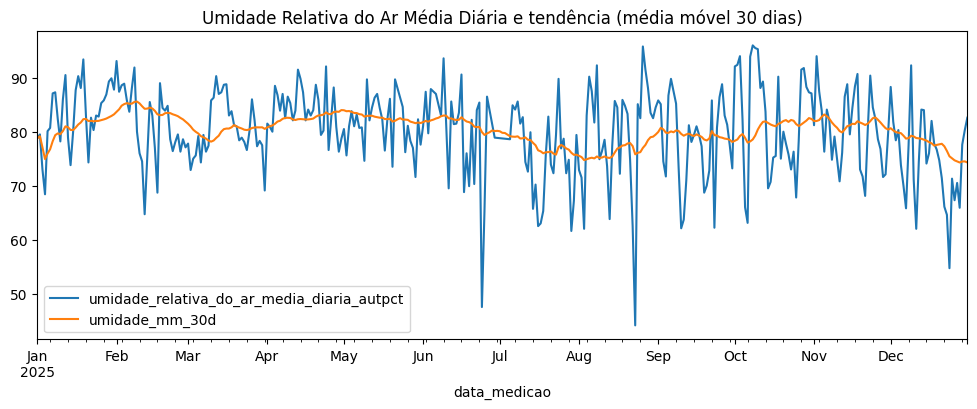

In [34]:
df['umidade_mm_30d'] = df['umidade_relativa_do_ar_media_diaria_autpct'].rolling(window=30, min_periods=1).mean()

df.plot(
    x='data_medicao',
    y=['umidade_relativa_do_ar_media_diaria_autpct', 'umidade_mm_30d'],
    figsize=(12,4),
    title='Umidade Relativa do Ar Média Diária e tendência (média móvel 30 dias)'
)

9.3.2 Regressão por Mínimos Quadrados

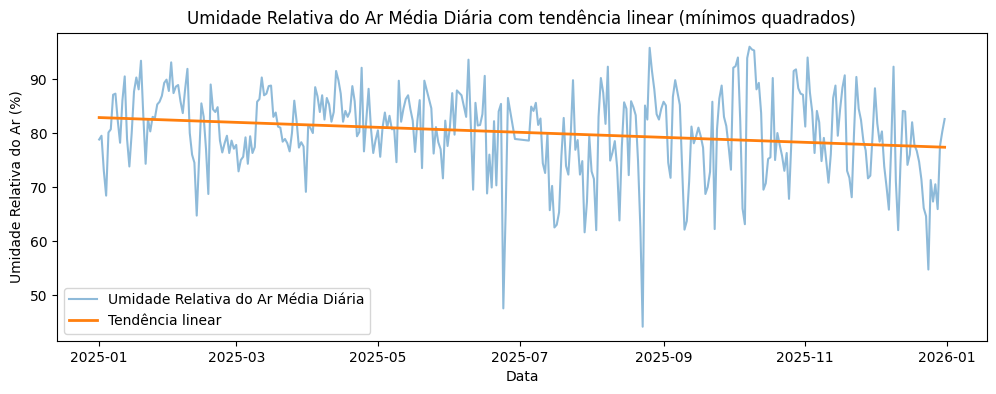

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# remover NaN
df_umidade = df[['data_medicao', 'umidade_relativa_do_ar_media_diaria_autpct']].dropna()

# variável independente (tempo como índice numérico)
x = np.arange(len(df_umidade))

# variável dependente
y = df_umidade['umidade_relativa_do_ar_media_diaria_autpct'].values


coef = np.polyfit(x, y, 1)  # grau 1 = reta
tendencia = np.polyval(coef, x)


plt.figure(figsize=(12,4))
plt.plot(df_umidade['data_medicao'], y, label='Umidade Relativa do Ar Média Diária', alpha=0.5)
plt.plot(df_umidade['data_medicao'], tendencia, label='Tendência linear', linewidth=2)

plt.xlabel('Data')
plt.ylabel('Umidade Relativa do Ar (%)')
plt.title('Umidade Relativa do Ar Média Diária com tendência linear (mínimos quadrados)')
plt.legend()
plt.show()

9.3.3 Teste de Cox-Stuart

In [36]:
serie_umidade = df['umidade_relativa_do_ar_media_diaria_autpct'].dropna().values

import numpy as np
from scipy.stats import binomtest

def cox_stuart_test(series):
    n = len(series)
    half = n // 2

    first_half = series[:half]
    second_half = series[-half:]

    diff = second_half - first_half

    pos = np.sum(diff > 0)
    neg = np.sum(diff < 0)

    result = binomtest(pos, pos + neg, 0.5)
    return result.pvalue

p_value_umidade = cox_stuart_test(serie_umidade)
p_value_umidade

if p_value_umidade < 0.05:
    print("Existe tendência significativa na série temporal de umidade.")
else:
    print("Não foi identificada tendência significativa na série temporal de umidade.")

Existe tendência significativa na série temporal de umidade.


#### 9.3.4 Boxplots Mensais

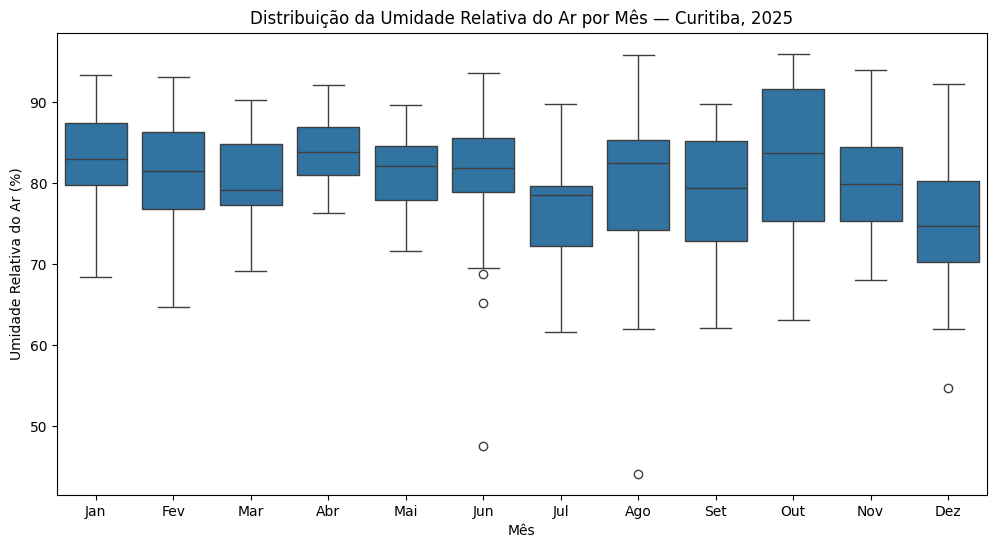

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'mes' column exists
if 'mes' not in df.columns:
    df['mes'] = df['data_medicao'].dt.month

mapa_meses = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr',
    5: 'Mai', 6: 'Jun', 7: 'Jul', 8: 'Ago',
    9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}

df['mes_nome'] = df['mes'].map(mapa_meses)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='mes_nome',
    y='umidade_relativa_do_ar_media_diaria_autpct',
    order=list(mapa_meses.values())
)

plt.xlabel('Mês')
plt.ylabel('Umidade Relativa do Ar (%)')
plt.title('Distribuição da Umidade Relativa do Ar por Mês — Curitiba, 2025')

plt.show()

#### 9.3.5 Teste de Kruskal–Wallis

In [38]:
from scipy.stats import kruskal
import pandas as pd
import numpy as np

# Ensure 'mes' column exists (if not created by previous cells)
if 'mes' not in df.columns:
    df['mes'] = df['data_medicao'].dt.month

# Group humidity data by month
monthly_humidity = [group['umidade_relativa_do_ar_media_diaria_autpct'].dropna().values for name, group in df.groupby('mes')]

# Perform Kruskal-Wallis H-test
h_statistic, p_value = kruskal(*monthly_humidity)

print(f"Kruskal-Wallis H-statistic: {h_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Existe uma diferença estatisticamente significativa na umidade entre os meses.")
else:
    print("Não há evidência de uma diferença estatisticamente significativa na umidade entre os meses.")

Kruskal-Wallis H-statistic: 43.75
P-value: 0.000
Existe uma diferença estatisticamente significativa na umidade entre os meses.


#### 9.3.6 Pós-teste de Dunn

In [48]:
# garantir coluna mês
df['mes'] = df['data_medicao'].dt.month

dunn_umidade = sp.posthoc_dunn(
    df,
    val_col='umidade_relativa_do_ar_media_diaria_autpct',
    group_col='mes',
    p_adjust='bonferroni'
)

dunn_umidade
dunn_umidade < 0.05

,1,2,3,4,5,6,7,8,9,10,11,12
1,False,False,False,False,False,False,True,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False,False,True
5,False,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False,False
7,True,False,False,True,False,False,False,False,False,True,False,False
8,False,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False,False
10,False,False,False,False,False,False,True,False,False,False,False,True


A umidade relativa média diária em Curitiba em 2025 apresentou diferenças estatisticamente significativas entre alguns meses. O teste de Kruskal–Wallis indicou variação mensal, e o pós-teste de Dunn mostrou que essas diferenças ocorrem de forma pontual entre meses específicos, enquanto a maior parte das comparações não apresentou diferenças significativas, sugerindo uma sazonalidade mais sutil e menos marcada quando comparada à temperatura.

### 9.4 Vento

#### 9.4.1 Média Móvel

<Axes: title={'center': 'Rajada Máxima Diária de Vento e tendência (média móvel 30 dias)'}, xlabel='data_medicao'>

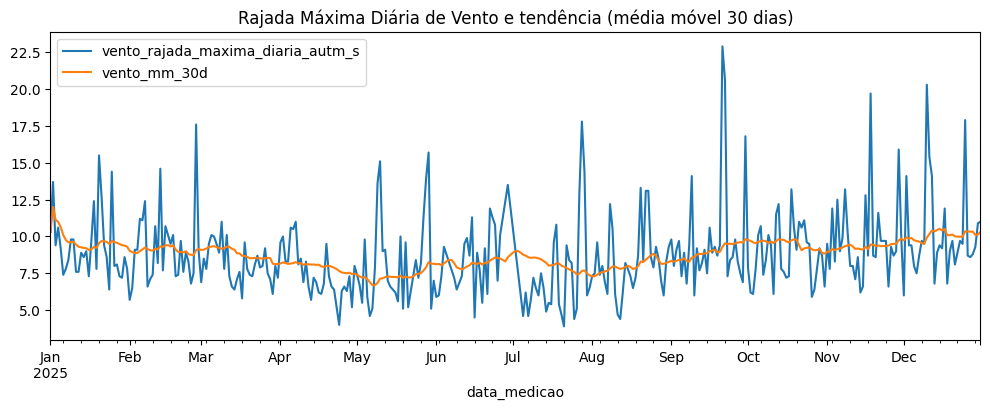

In [39]:
df['vento_mm_30d'] = df['vento_rajada_maxima_diaria_autm_s'].rolling(window=30, min_periods=1).mean()

df.plot(
    x='data_medicao',
    y=['vento_rajada_maxima_diaria_autm_s', 'vento_mm_30d'],
    figsize=(12,4),
    title='Rajada Máxima Diária de Vento e tendência (média móvel 30 dias)'
)

#### 9.4.2 Regressão por Mínimos Quadrados

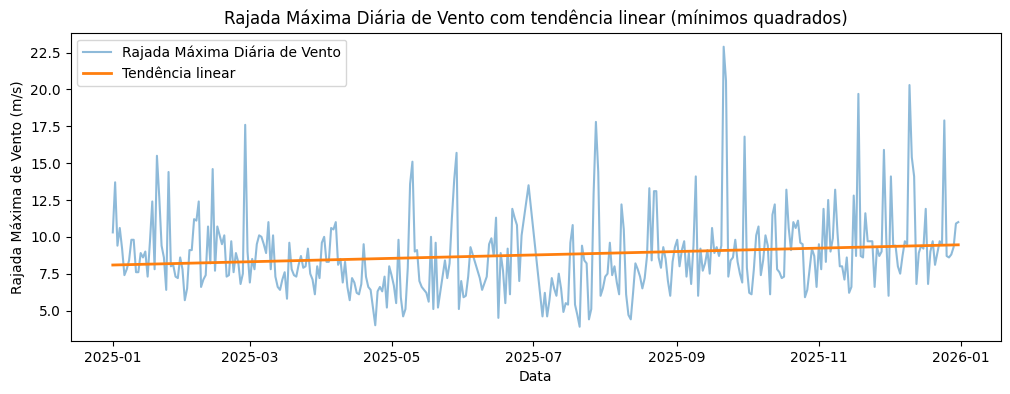

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# remover NaN
df_vento = df[['data_medicao', 'vento_rajada_maxima_diaria_autm_s']].dropna()

# variável independente (tempo como índice numérico)
x = np.arange(len(df_vento))

# variável dependente
y = df_vento['vento_rajada_maxima_diaria_autm_s'].values


coef = np.polyfit(x, y, 1)  # grau 1 = reta
tendencia = np.polyval(coef, x)


plt.figure(figsize=(12,4))
plt.plot(df_vento['data_medicao'], y, label='Rajada Máxima Diária de Vento', alpha=0.5)
plt.plot(df_vento['data_medicao'], tendencia, label='Tendência linear', linewidth=2)

plt.xlabel('Data')
plt.ylabel('Rajada Máxima de Vento (m/s)')
plt.title('Rajada Máxima Diária de Vento com tendência linear (mínimos quadrados)')
plt.legend()
plt.show()

#### 9.4.3 Teste de Cox-Stuart

In [41]:
serie_vento = df['vento_rajada_maxima_diaria_autm_s'].dropna().values

import numpy as np
from scipy.stats import binomtest

def cox_stuart_test(series):
    n = len(series)
    half = n // 2

    first_half = series[:half]
    second_half = series[-half:]

    diff = second_half - first_half

    pos = np.sum(diff > 0)
    neg = np.sum(diff < 0)

    result = binomtest(pos, pos + neg, 0.5)
    return result.pvalue

p_value_vento = cox_stuart_test(serie_vento)
p_value_vento

if p_value_vento < 0.05:
    print("Existe tendência significativa na série temporal de vento.")
else:
    print("Não foi identificada tendência significativa na série temporal de vento.")

Não foi identificada tendência significativa na série temporal de vento.


#### 9.4.4 Boxplots Mensais

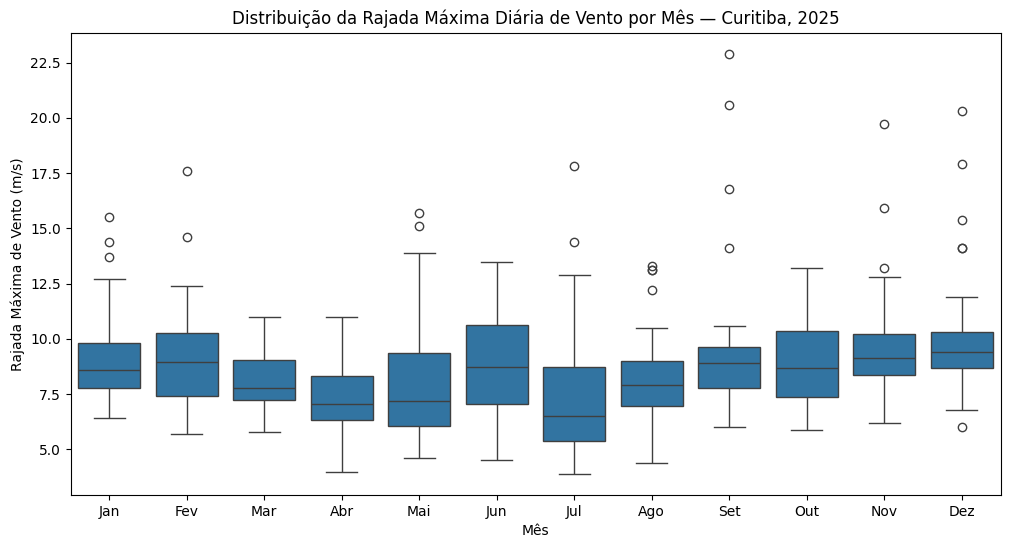

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'mes' column exists
if 'mes' not in df.columns:
    df['mes'] = df['data_medicao'].dt.month

mapa_meses = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr',
    5: 'Mai', 6: 'Jun', 7: 'Jul', 8: 'Ago',
    9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}

df['mes_nome'] = df['mes'].map(mapa_meses)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='mes_nome',
    y='vento_rajada_maxima_diaria_autm_s',
    order=list(mapa_meses.values())
)

plt.xlabel('Mês')
plt.ylabel('Rajada Máxima de Vento (m/s)')
plt.title('Distribuição da Rajada Máxima Diária de Vento por Mês — Curitiba, 2025')

plt.show()

#### 9.4.5 Teste de Kruskal–Wallis

In [43]:
from scipy.stats import kruskal
import pandas as pd
import numpy as np

# Ensure 'mes' column exists (if not created by previous cells)
if 'mes' not in df.columns:
    df['mes'] = df['data_medicao'].dt.month

# Group wind data by month
monthly_wind = [group['vento_rajada_maxima_diaria_autm_s'].dropna().values for name, group in df.groupby('mes')]

# Perform Kruskal-Wallis H-test
h_statistic, p_value = kruskal(*monthly_wind)

print(f"Kruskal-Wallis H-statistic: {h_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Existe uma diferença estatisticamente significativa na rajada máxima diária de vento entre os meses.")
else:
    print("Não há evidência de uma diferença estatisticamente significativa na rajada máxima diária de vento entre os meses.")

Kruskal-Wallis H-statistic: 48.64
P-value: 0.000
Existe uma diferença estatisticamente significativa na rajada máxima diária de vento entre os meses.


#### 9.4.6 Pós-teste de Dunn

In [50]:
# garantir coluna mês
df['mes'] = df['data_medicao'].dt.month

dunn_vento = sp.posthoc_dunn(
    df,
    val_col='vento_rajada_maxima_diaria_autm_s',
    group_col='mes',
    p_adjust='bonferroni'
)

dunn_vento
dunn_vento < 0.05

,1,2,3,4,5,6,7,8,9,10,11,12
1,False,False,False,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,True
5,False,False,False,False,False,False,False,False,False,False,False,True
6,False,False,False,False,False,False,False,False,False,False,False,False
7,True,False,False,False,False,False,False,False,True,False,True,True
8,False,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,True,False,False,False,False,False
10,False,False,False,False,False,False,False,False,False,False,False,False


A rajada máxima diária do vento em Curitiba em 2025 apresentou diferenças estatisticamente significativas entre alguns meses específicos. O teste de Kruskal–Wallis indicou variação mensal, e o pós-teste de Dunn mostrou que essas diferenças ocorrem de forma pontual alguns meses somente, enquanto a maior parte das comparações não apresentou diferenças significativas, sugerindo uma sazonalidade mais sutil e pouco marcada ao longo do ano.

### 9.5 Síntese dos Resultados de Tendência e Sazonalidade

A análise integrada das variáveis climáticas em Curitiba ao longo de 2025 evidencia comportamentos distintos em termos de tendência temporal, variabilidade e sazonalidade. A temperatura média diária destacou-se como a variável com padrão mais consistente, apresentando tendência significativa de diminuição ao longo do ano e uma sazonalidade bem definida, com diferenças claras entre os meses de verão e inverno.

A precipitação diária mostrou elevada variabilidade ao longo do ano, caracterizada por grande dispersão e presença frequente de valores extremos, especialmente nos meses de verão. Embora não tenha sido identificada tendência significativa, a sazonalidade foi estatisticamente relevante, com diferenças predominantes entre meses de estações distintas, refletindo o regime pluviométrico típico da região.

A umidade relativa do ar apresentou tendência significativa de diminuição, porém com medianas relativamente estáveis ao longo dos meses. A sazonalidade mostrou-se mais sutil, com diferenças estatisticamente significativas restritas a comparações pontuais entre meses específicos, indicando menor contraste sazonal quando comparada à temperatura e à precipitação.

A rajada máxima diária de vento não apresentou tendência significativa e exibiu medianas mensais semelhantes ao longo do ano, acompanhadas por considerável número de eventos extremos isolados. A sazonalidade foi limitada, com diferenças estatísticas concentradas em poucos pares de meses, sugerindo que a variabilidade do vento está mais associada a eventos episódicos do que a um ciclo sazonal bem definido.

De forma geral, os resultados indicam que a **temperatura** apresenta o comportamento mais regular e previsível, a **precipitação** concentra a maior variabilidade e sensibilidade sazonal, enquanto **umidade** e **vento** exibem padrões mais moderados, com variações pontuais ao longo do ano. Essa combinação de comportamentos reforça a importância de análises multivariadas para a compreensão integrada da dinâmica climática local.
